:**Food Recommender System ด้วย Graph** <br>แนวคิดคือ ผู้ใช้กินหรือชอบอาหารอะไร → หา User คนอื่นที่ชอบอาหารคล้ายกัน → ดูว่าคนเหล่านั้นชอบอาหารอะไรอีก → แนะนำอาหารนั้นกลับมา

ตัวอย่างสถานการณ์  มีผู้ใช้ 4 คน <br>

```
 "John",
    "Billy",
    "Chanom",
    "Pop",
    "Alex",
    "Sarah",
    "David",
    "Emma",
    "Michael",
    "Sophia
```

และมีอาหาร

```
"noodle",
    "kaolao",
    "Kapawmoosaab",
    "fried rice",
    "Rad Na",
    "Pad Thai",
    "Tom Yum Goong",
    "Som Tum",
    "Green Curry",
    "Kao Mun Gai"
```

สมมติข้อมูลความชอบคือ

```
John   → ก๋วยเตี๋ยว
John   → เกาเหลา

Billy     → ก๋วยเตี๋ยว
Billy     → เกาเหลา
Billy   → ข้าวผัด


Chanom → ก๋วยเตี๋ยว
Chanom → กระเพราหมูสับ


Pop  → ข้าวผัด
Pop   → ราดหน้า
```



```
เราจะสังเกตได้ว่า

John และ Billy ชอบ ก็วยเตี๋ยว และ เกาเหลา เหมือนกัน

แต่ Bob ยังชอบ

ข้าวผัด

ดังนั้นระบบสามารถคิดง่าย ๆ ว่า

ถ้า John กับ Billy มีความชอบคล้ายกัน
และ Billy ชอบ ข้าวผัด แต่ John ยังไม่ได้เลือก ข้าวผัด
ระบบอาจแนะนำ ข้าวผัด ให้ John

นี่คือ Recommender System แบบ Graph อย่างง่ายค่ะ
```



การออกแบบ Graph

```
เราแบ่ง Node เป็น 2 ประเภท

User
Food

Relationship คือ

LIKES

ดังนั้น

(User)-[:LIKES]->(Food)

เช่น

(John)-[:LIKES]->(ก๋วยเตี๋ยว)

หรือถ้าเป็น Python NetworkX

G.add_edge("John", "ข้าวผัด")
```


**สร้างด้วย Python บน Google Colab**

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
G = nx.Graph()

In [ ]:
#add user
users = [
   "John",
    "Billy",
    "Chanom",
    "Pop",
    "Alex",
    "Sarah",
    "David",
    "Emma",
    "Michael",
    "Sophia"
]

for user in users:
    G.add_node(
        user,
        node_type="user"
    )

In [ ]:
#add Foods
foods = [
   "noodle",
    "kaolao",
    "Kapawmoosaab",
    "fried rice",
    "Rad Na",
    "Pad Thai",
    "Tom Yum Goong",
    "Som Tum",
    "Green Curry",
    "Kao Mun Gai"
]

for food in foods:
    G.add_node(
        food,
        node_type="food"
    )

In [ ]:
#add relationship
likes = [
    # ของเดิม
    ("John", "noodle"),
    ("John", "kaolao"),

    ("Billy", "noodle"),
    ("Billy", "kaolao"),
    ("Billy", "fried rice"),

    ("Chanom", "noodle"),
    ("Chanom", "Kapawmoosaab"),

    ("Pop", "fried rice"),
    ("Pop", "Rad Na"),

    ("Alex", "Pad Thai"),
    ("Alex", "Tom Yum Goong"),

    ("Sarah", "Som Tum"),
    ("Sarah", "Green Curry"),

    ("David", "Kao Mun Gai"),
    ("David", "fried rice"),

    ("Emma", "Pad Thai"),
    ("Emma", "noodle"),

    ("Michael", "Tom Yum Goong"),
    ("Michael", "Kapawmoosaab"),

    ("Sophia", "Som Tum"),
    ("Sophia", "Rad Na")
]

เพิ่มเข้า Graph

In [ ]:
G.add_edges_from(likes)

วาด Graph

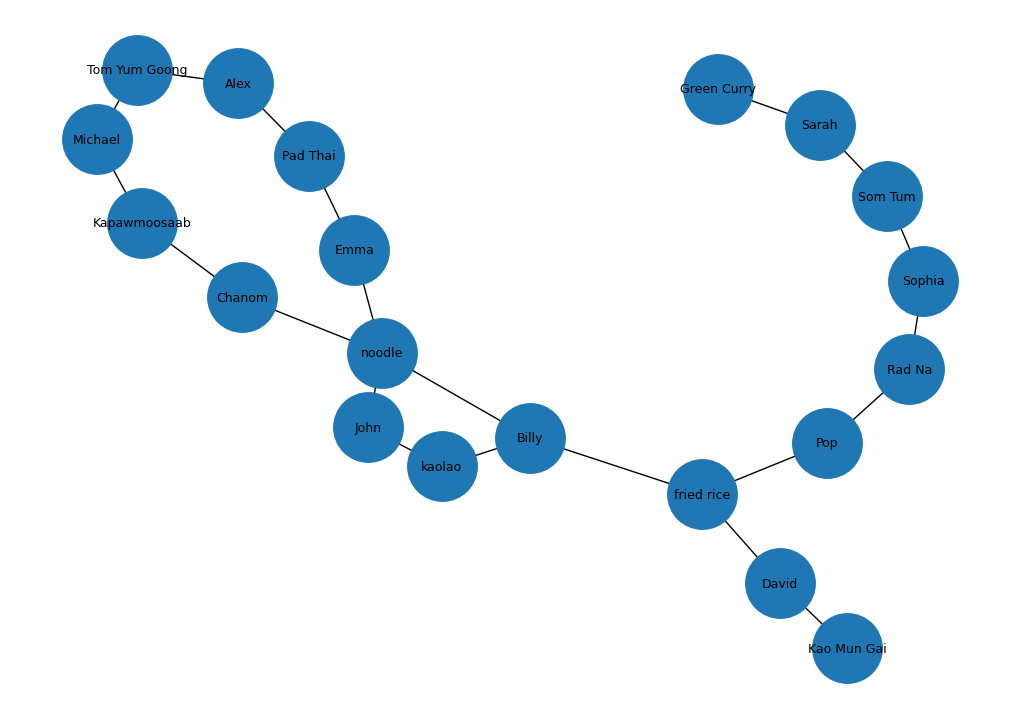

In [ ]:
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

plt.show()

คำถามแรก <br>
1.ถามว่า John ชอบอาหารอะไรบ้าง?

In [ ]:
John_foods = list(
    G.neighbors("John")
)

print(John_foods)

['noodle', 'kaolao']


ตรงนี้อธิบายได้ว่า Neighbor ของ John คือ Node ที่เชื่อมกับ John

คำถามที่ 2. หา User ที่ชอบอาหารเหมือน John <br>
John ชอบ  Noodle กับ Kaolao <br>
เราสามารถหาได้ว่าใครชอบหนังเหล่านี้เหมือนกัน

In [ ]:
for food in G.neighbors("John"):

    print("Food:", food)

    for user in G.neighbors(food):

        if user != "John":
            print("  Similar user:", user)

Food: noodle
  Similar user: Billy
  Similar user: Chanom
  Similar user: Emma
Food: kaolao
  Similar user: Billy


**สร้าง Recommendation แบบง่าย**

```
แนวคิดคือ

John
 ↓
อาหารที่ John ชอบ
 ↓
User ที่ชอบอาหารเดียวกัน
 ↓
อาหารอื่นที่ User เหล่านั้นชอบ
 ↓
แนะนำให้ John
```



In [ ]:
from collections import Counter


target_user = "John"

recommendations = Counter()


# อาหารที่ John ชอบแล้ว
liked_foods = set(
    G.neighbors(target_user)
)


# อาหารแต่ละอย่างที่ John ชอบ
for food in liked_foods:

    # หา User ที่ชอบอาหารเดียวกัน
    for similar_user in G.neighbors(food):

        if similar_user == target_user:
            continue

        # ดูว่า User คนนั้นชอบอาหารอะไรอีก
        for other_food in G.neighbors(similar_user):

            #John ยังไม่เคยชอบอาหารนี้
            if other_food not in liked_foods:

                recommendations[other_food] += 1


print(recommendations)

Counter({'fried rice': 2, 'Kapawmoosaab': 1, 'Pad Thai': 1})


Kapawmoosaab **bold text** ถูกพบจาก User ที่มีความสัมพันธ์กับ John จำนวน 1 ครั้ง

In [ ]:
# นำไปสร้างเป็นฟังก์ชัน

In [ ]:
from collections import Counter


def recommend_foods(G, target_user):

    recommendations = Counter()

    liked_foods = set(
        G.neighbors(target_user)
    )

    for food in liked_foods:

        for similar_user in G.neighbors(food):

            if similar_user == target_user:
                continue

            for other_food in G.neighbors(similar_user):

                if other_food not in liked_foods:

                    recommendations[other_food] += 1

    return recommendations.most_common()

In [ ]:
#เรียกใช้งาน
result = recommend_foods( G, "John")
print(result)

[('fried rice', 2), ('Kapawmoosaab', 1), ('Pad Thai', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_foods( G, "Chanom")
print(result)

[('kaolao', 2), ('Tom Yum Goong', 1), ('fried rice', 1), ('Pad Thai', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_foods( G, "Billy")
print(result)

[('Rad Na', 1), ('Kao Mun Gai', 1), ('Kapawmoosaab', 1), ('Pad Thai', 1)]


In [ ]:
john_foods = list(
    G.neighbors("John")
)

print(john_foods)

['noodle', 'kaolao']


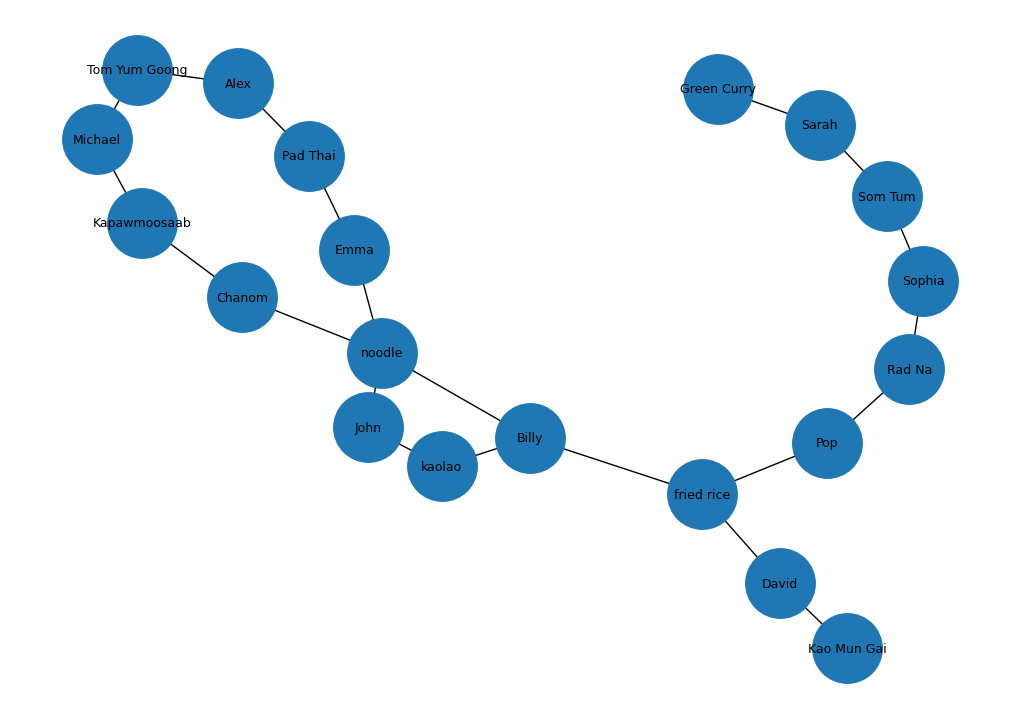

Recommendations for Pop
noodle Score = 1
kaolao Score = 1
Kao Mun Gai Score = 1
Som Tum Score = 1


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

from collections import Counter


# ==================================
# 1. Create Graph
# ==================================

G = nx.Graph()


# ==================================
# 2. Add Users
# ==================================

users = [
    "John",
    "Billy",
    "Chanom",
    "Pop",
    "Alex",
    "Sarah",
    "David",
    "Emma",
    "Michael",
    "Sophia"
]

for user in users:

    G.add_node(
        user,
        node_type="user"
    )


# ==================================
# 3. Add Foods
# ==================================

foods = [
    "noodle",
    "kaolao",
    "Kapawmoosaab",
    "fried rice",
    "Rad Na",
    "Pad Thai",
    "Tom Yum Goong",
    "Som Tum",
    "Green Curry",
    "Kao Mun Gai"
]

for food in foods:

    G.add_node(
        food,
        node_type="food"
    )


# ==================================
# 4. User-Food Relationships
# ==================================

likes = [

    ("John", "noodle"),
    ("John", "kaolao"),

    ("Billy", "noodle"),
    ("Billy", "kaolao"),
    ("Billy", "fried rice"),

    ("Chanom", "noodle"),
    ("Chanom", "Kapawmoosaab"),

    ("Pop", "fried rice"),
    ("Pop", "Rad Na"),

    ("Alex", "Pad Thai"),
    ("Alex", "Tom Yum Goong"),

    ("Sarah", "Som Tum"),
    ("Sarah", "Green Curry"),

    ("David", "Kao Mun Gai"),
    ("David", "fried rice"),

    ("Emma", "Pad Thai"),
    ("Emma", "noodle"),

    ("Michael", "Tom Yum Goong"),
    ("Michael", "Kapawmoosaab"),

    ("Sophia", "Som Tum"),
    ("Sophia", "Rad Na")
]


G.add_edges_from(likes)


# ==================================
# 5. Draw Graph
# ==================================

plt.figure(
    figsize=(10, 7)
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)


plt.show()


# ==================================
# 6. Recommendation Function
# ==================================

def recommend_foods(
    G,
    target_user
):

    recommendations = Counter()

    liked_foods = set(
        G.neighbors(
            target_user
        )
    )

    for food in liked_foods:

        for similar_user in G.neighbors(food):

            if similar_user == target_user:
                continue

            for other_food in G.neighbors(
                similar_user
            ):

                if other_food not in liked_foods:

                    recommendations[
                        other_food
                    ] += 1

    return recommendations.most_common()


# ==================================
# 7. Recommend for John
# ==================================

target_user = "Pop"

result = recommend_foods(
    G,
    target_user
)


print(
    "Recommendations for",
    target_user
)


for food, score in result:

    print(
        food,
        "Score =",
        score
    )

Recommender System แบบ Graph ไม่ได้มองเพียงว่า “อาหารไหนดี” แต่ดูว่า “ผู้ใช้คนนี้เชื่อมโยงกับผู้ใช้และอาหารอื่นอย่างไร”